# LendFast Application Conversion Analysis
## Exploratory Data Analysis

**Business Context:**
LendFast is a digital consumer lending startup with 45,000 registered 
users and a 7-step loan application process. Despite significant 
marketing investment, application completion rates fall well below 
the 63% industry abandonment benchmark (Signicat, 2025).

**Objective:**
Identify where and why users abandon the application process to 
inform targeted UX, process, and re-engagement recommendations.

**Dataset:**
2,350 application records covering January 2023 to June 2024, 
containing step-level completion data, user demographics, 
device type, and time on application.

**Analytical Approach:**
1. Data quality check
2. Overall funnel analysis
3. Segmentation analysis
4. Hypothesis validation
5. Key findings summary

## Hypotheses Under Investigation

Nine hypotheses were developed before any data was examined. 
Each is tested during the analysis and marked confirmed, 
partially confirmed, rejected, or cannot be assessed.

| ID | Hypothesis | Test Location |
|---|---|---|
| H1 | Steps 2 and 3 have above-average drop-off rates because employment and income fields require information users may not have readily available | Section 2 — Funnel Analysis |
| H2 | Self-employed users abandon at Steps 2 and 3 at significantly higher rates than employed users because standard fields don't accommodate variable income | Section 3 — Segmentation |
| H3 | Users with poor and fair credit scores abandon at Step 5 at higher rates than good and excellent users due to fear of hard credit inquiry impact | Section 3 — Segmentation |
| H4 | Step 6 (Document Upload) has the highest single-step drop-off rate driven by document unavailability and trust concerns | Section 2 — Funnel Analysis |
| H5 | Mobile users complete at significantly lower rates than desktop users due to friction at document upload and form completion on small screens | Section 3 — Segmentation |
| H6 | Higher loan amounts correlate with higher drop-off at Step 4 due to fear of rejection or uncertainty about repayment costs | Section 3 — Segmentation |
| H7 | Drop-off rates show quarterly variation due to external economic conditions influencing applicant confidence | Section 3 — Segmentation |
| H8 | Users who abandon in under 10 minutes encountered an early barrier. Users spending over 30 minutes faced procedural friction or document unavailability | Section 1 — Data Quality |
| H9 | A measurable proportion of abandonment is caused by technical failures — application errors, session timeouts, and upload failures | Cannot be assessed — telemetry data required |

**H8 and H9 are addressed during data quality analysis.**
**H1 and H4 are confirmed in the funnel analysis.**
**H2, H3, H5, H6, and H7 are tested in segmentation.**

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Blues_d')

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/geethika123/lendfast-applications/lendfast_applications.csv',
                 parse_dates=['application_start_date'])

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDate range: {df['application_start_date'].min().date()} "
      f"to {df['application_start_date'].max().date()}")
df.head()

Dataset loaded: 2350 rows, 12 columns

Columns: ['application_id', 'user_id', 'application_start_date', 'user_type', 'employment_status', 'credit_score_band', 'device_type', 'loan_amount_requested', 'step_reached', 'application_completed', 'loan_approved', 'time_on_application_mins']

Date range: 2023-01-01 to 2024-06-29


,application_id,user_id,application_start_date,user_type,employment_status,credit_score_band,device_type,loan_amount_requested,step_reached,application_completed,loan_approved,time_on_application_mins
0,APP-00001,USR-00999,2023-06-14,new_user,employed,excellent,desktop,47000,5,no,NaN,10
1,APP-00002,USR-01096,2023-11-10,rejected_reapply,employed,good,mobile,8000,7,yes,yes,32
2,APP-00003,USR-00048,2023-01-21,new_user,self-employed,fair,mobile,26000,2,no,NaN,14
3,APP-00004,USR-00942,2023-03-23,new_user,self-employed,fair,mobile,15000,0,no,NaN,6
4,APP-00005,USR-00074,2023-05-11,new_user,employed,fair,mobile,1000,0,no,NaN,6


## Section 1: Data Quality Assessment

### 1.1 Data Types Verification

Before any analysis, each column is confirmed to be stored in the correct 
data type. Incorrect types cause silent errors — for example, 
a date stored as a string won't sort chronologically, and a 
categorical column stored as an integer will be treated as a 
continuous variable in aggregations.

Expected types:
- application_id, user_id: object (string identifiers)
- application_start_date: datetime64
- user_type, employment_status, credit_score_band, 
  device_type, application_completed, loan_approved: object (categorical)
- loan_amount_requested, step_reached, 
  time_on_application_mins: int64 or float64

In [2]:
# Data types verification
print("=" * 55)
print("DATA TYPES")
print("=" * 55)
print(df.dtypes)

print("\n" + "=" * 55)
print("DATASET SHAPE")
print("=" * 55)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

print("\n" + "=" * 55)
print("SAMPLE ROWS")
print("=" * 55)
df.head(3)

DATA TYPES
application_id                      object
user_id                             object
application_start_date      datetime64[ns]
user_type                           object
employment_status                   object
credit_score_band                   object
device_type                         object
loan_amount_requested                int64
step_reached                         int64
application_completed               object
loan_approved                       object
time_on_application_mins             int64
dtype: object

DATASET SHAPE
Rows    : 2,350
Columns : 12

SAMPLE ROWS


,application_id,user_id,application_start_date,user_type,employment_status,credit_score_band,device_type,loan_amount_requested,step_reached,application_completed,loan_approved,time_on_application_mins
0,APP-00001,USR-00999,2023-06-14,new_user,employed,excellent,desktop,47000,5,no,NaN,10
1,APP-00002,USR-01096,2023-11-10,rejected_reapply,employed,good,mobile,8000,7,yes,yes,32
2,APP-00003,USR-00048,2023-01-21,new_user,self-employed,fair,mobile,26000,2,no,NaN,14


### 1.2 Missing Values Analysis

Missing values are quantified as a percentage per column rather 
than raw counts — a count of 100 missing values means something 
very different in a 200-row dataset versus a 2,350-row dataset.

Key distinction for this dataset:
- loan_approved nulls are EXPECTED and structurally valid — 
  only completed applications receive an approval decision. 
  This is Missing Not At Random (MNAR) — the missingness is 
  directly related to the value of application_completed.
- Any unexpected nulls in other columns signal a data 
  collection failure requiring investigation before analysis proceeds.

In [3]:
# Missing values analysis
print("=" * 55)
print("MISSING VALUES ANALYSIS")
print("=" * 55)

missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

missing = missing[missing['missing_count'] > 0]

if missing.empty:
    print("No missing values found.")
else:
    print(missing.to_string())

# Validate loan_approved nulls are structurally expected
print("\n" + "=" * 55)
print("LOAN_APPROVED — MISSING PATTERN VALIDATION")
print("=" * 55)

# All nulls should correspond to incomplete applications
null_approved = df[df['loan_approved'].isnull()]
unexpected = null_approved[null_approved['application_completed'] == 'yes']

print(f"Total null loan_approved       : {df['loan_approved'].isnull().sum()}")
print(f"Incomplete applications        : {(df['application_completed']=='no').sum()}")
print(f"Unexpected nulls (completed=yes): {len(unexpected)}")

if len(unexpected) == 0:
    print("\n✓ All loan_approved nulls are structurally valid.")
    print("  Missingness is MNAR — directly linked to application_completed.")
else:
    print(f"\n⚠ {len(unexpected)} unexpected nulls found — investigate.")

MISSING VALUES ANALYSIS
               missing_count  missing_pct
loan_approved           1923        81.83

LOAN_APPROVED — MISSING PATTERN VALIDATION
Total null loan_approved       : 1923
Incomplete applications        : 1923
Unexpected nulls (completed=yes): 0

✓ All loan_approved nulls are structurally valid.
  Missingness is MNAR — directly linked to application_completed.


### 1.3 Duplicate Detection

Two types of duplicates are checked:

1. **Fully duplicate rows** — identical values across all columns.
   These suggest data ingestion errors where the same record 
   was loaded twice.

2. **Duplicate primary keys** — repeated application_id values.
   Since application_id is the primary key, any duplication 
   here means two distinct records are sharing the same 
   identifier — a critical data integrity failure that would 
   corrupt aggregations and counts.

Note: user_id duplication is expected and not treated as an 
error — the same user can start multiple applications.

**Known Data Limitation — Application Lineage:**
The current dataset treats each application attempt as an independent 
record with a unique application_id. While backend systems likely 
retain partial submission data, no parent_application_id linkage 
exists to trace relationships between a user's multiple attempts.

A recommended schema improvement is to add a parent_application_id 
column — null for first attempts, populated with the previous 
application_id for restarts. This would enable conversion analysis 
across multiple attempts per user.

For this analysis, returning user attempts are identified via 
user_type = 'abandoned_restart' or 'rejected_reapply' as a proxy.

In [4]:
print("=" * 55)
print("DUPLICATE DETECTION")
print("=" * 55)

# Check 1 — fully duplicate rows
full_dupes = df.duplicated().sum()
print(f"Fully duplicate rows     : {full_dupes}")

# Check 2 — duplicate primary keys
pk_dupes = df.duplicated(subset=['application_id']).sum()
print(f"Duplicate application_id : {pk_dupes}")

# Check 3 — user_id duplicates (expected — returning users)
user_counts = df['user_id'].value_counts()
returning = (user_counts > 1).sum()
max_attempts = user_counts.max()
print(f"\nUnique users             : {df['user_id'].nunique():,}")
print(f"Total application records: {len(df):,}")
print(f"Users with >1 application: {returning:,}")
print(f"Max applications per user: {max_attempts}")

# Show distribution of attempts per user
print(f"\nApplication attempts per user:")
attempt_dist = user_counts.value_counts().sort_index()
for attempts, count in attempt_dist.items():
    print(f"  {attempts} application(s): {count:,} users")

if full_dupes == 0 and pk_dupes == 0:
    print("\n✓ No duplicate rows or primary key violations found.")
    print("  User_id repeats are expected — returning applicants.")
else:
    print(f"\n⚠ Data integrity issue detected — investigate before proceeding.")

DUPLICATE DETECTION
Fully duplicate rows     : 0
Duplicate application_id : 0

Unique users             : 1,926
Total application records: 2,350
Users with >1 application: 302
Max applications per user: 6

Application attempts per user:
  1 application(s): 1,624 users
  2 application(s): 206 users
  3 application(s): 74 users
  4 application(s): 19 users
  5 application(s): 2 users
  6 application(s): 1 users

✓ No duplicate rows or primary key violations found.
  User_id repeats are expected — returning applicants.


### 1.4 Categorical Values Inspection

Frequency tables are run on all categorical columns to detect:
- Misspelled categories (e.g. 'Self-Employed' vs 'self-employed')
- Hidden missing value encodings (e.g. 'N/A', '?', 'unknown', '-1')
- Casing inconsistencies
- Unexpected values outside the defined category set

Expected categories per column:
- employment_status: employed, self-employed, unemployed, student
- credit_score_band: poor, fair, good, excellent
- device_type: mobile, desktop, tablet
- application_completed: yes, no
- loan_approved: yes, no (nulls already validated in Step 1.2)
- user_type: new_user, abandoned_restart, rejected_reapply, second_loan

In [5]:
print("=" * 55)
print("CATEGORICAL VALUES INSPECTION")
print("=" * 55)

categorical_cols = ['employment_status', 'credit_score_band', 
                    'device_type', 'application_completed',
                    'loan_approved', 'user_type']

expected_values = {
    'employment_status'  : {'employed','self-employed','unemployed','student'},
    'credit_score_band'  : {'poor','fair','good','excellent'},
    'device_type'        : {'mobile','desktop','tablet'},
    'application_completed': {'yes','no'},
    'loan_approved'      : {'yes','no'},
    'user_type'          : {'new_user','abandoned_restart',
                            'rejected_reapply','second_loan'}
}

for col in categorical_cols:
    print(f"\n{col.upper()}")
    print("-" * 40)
    
    freq = df[col].value_counts(dropna=False)
    pct  = df[col].value_counts(dropna=False, normalize=True).mul(100).round(1)
    
    summary = pd.DataFrame({'count': freq, 'pct_%': pct})
    print(summary.to_string())
    
    # Check for unexpected values
    actual_values = set(df[col].dropna().unique())
    unexpected = actual_values - expected_values[col]
    
    if unexpected:
        print(f"  ⚠ Unexpected values found: {unexpected}")
    else:
        print(f"  ✓ All values within expected set")

CATEGORICAL VALUES INSPECTION

EMPLOYMENT_STATUS
----------------------------------------
                   count  pct_%
employment_status              
employed            1477   62.9
self-employed        537   22.9
unemployed           245   10.4
student               91    3.9
  ✓ All values within expected set

CREDIT_SCORE_BAND
----------------------------------------
                   count  pct_%
credit_score_band              
good                 959   40.8
fair                 592   25.2
excellent            467   19.9
poor                 332   14.1
  ✓ All values within expected set

DEVICE_TYPE
----------------------------------------
             count  pct_%
device_type              
mobile        1426   60.7
desktop        680   28.9
tablet         244   10.4
  ✓ All values within expected set

APPLICATION_COMPLETED
----------------------------------------
                       count  pct_%
application_completed              
no                      1923   81.8
yes  

### 1.5 Numerical Range Validation

Minimum and maximum values are checked against logical business 
boundaries to detect impossible values or data entry errors.

Expected ranges:
- loan_amount_requested: $1,000 to $50,000 (LendFast product range)
- step_reached: 0 to 7 (seven application steps, 0 = dropped before step 1)
- time_on_application_mins: > 0 (negative time is impossible)

Extreme values in time_on_application_mins are not automatically 
treated as errors — a user spending 90+ minutes may reflect 
genuine behaviour such as document retrieval or deliberate pausing. 
These are flagged for investigation not removal.

In [6]:
print("=" * 55)
print("NUMERICAL RANGE VALIDATION")
print("=" * 55)

numerical_cols = {
    'loan_amount_requested'   : (1000, 50000),
    'step_reached'            : (0, 7),
    'time_on_application_mins': (1, None)  # no upper bound — flag extremes
}

for col, (min_expected, max_expected) in numerical_cols.items():
    print(f"\n{col.upper()}")
    print("-" * 40)
    
    stats = df[col].describe().round(2)
    print(stats.to_string())
    
    # Check minimum
    actual_min = df[col].min()
    if actual_min < min_expected:
        print(f"  ⚠ Values below minimum ({min_expected}): "
              f"{(df[col] < min_expected).sum()} records")
    else:
        print(f"  ✓ Minimum {actual_min} within expected range")
    
    # Check maximum if defined
    if max_expected is not None:
        actual_max = df[col].max()
        if actual_max > max_expected:
            print(f"  ⚠ Values above maximum ({max_expected}): "
                  f"{(df[col] > max_expected).sum()} records")
        else:
            print(f"  ✓ Maximum {actual_max} within expected range")
    
    # Flag extremes for time column
        # Flag extremes for time column
    if col == 'time_on_application_mins':
        under_3   = (df[col] < 3).sum()
        over_90   = (df[col] > 90).sum()
        
        # Meaningful threshold — applied to completers only
        completed = df[df['application_completed'] == 'yes']
        suspicious_completions = (completed['time_on_application_mins'] < 15).sum()
        
        print(f"\n  Extreme value flags:")
        print(f"  Under 3 mins (all users)     : {under_3:,} records "
              f"({under_3/len(df)*100:.1f}%) — immediate abandonment")
        print(f"  Over 90 mins (all users)     : {over_90:,} records "
              f"({over_90/len(df)*100:.1f}%) — flag for investigation")
        print(f"\n  Completed applications under 15 mins: "
              f"{suspicious_completions} "
              f"({suspicious_completions/len(completed)*100:.1f}% of completions)")
        print(f"  Note: Sub-15-min completions may indicate pre-filled "
              f"data, returning users, or data quality issues")

NUMERICAL RANGE VALIDATION

LOAN_AMOUNT_REQUESTED
----------------------------------------
count     2350.00
mean     25561.70
std      14500.96
min       1000.00
25%      13000.00
50%      25000.00
75%      38000.00
max      50000.00
  ✓ Minimum 1000 within expected range
  ✓ Maximum 50000 within expected range

STEP_REACHED
----------------------------------------
count    2350.00
mean        4.03
std         2.16
min         0.00
25%         2.00
50%         5.00
75%         5.00
max         7.00
  ✓ Minimum 0 within expected range
  ✓ Maximum 7 within expected range

TIME_ON_APPLICATION_MINS
----------------------------------------
count    2350.00
mean       19.18
std        14.96
min         1.00
25%         6.00
50%        15.00
75%        29.00
max        67.00
  ✓ Minimum 1 within expected range

  Extreme value flags:
  Under 3 mins (all users)     : 112 records (4.8%) — immediate abandonment
  Over 90 mins (all users)     : 0 records (0.0%) — flag for investigation

  Comple

### 1.6 Outlier Detection — Time on Application

Two visualisations are used to understand the time distribution:

1. **Histogram** — reveals the overall distribution shape and 
   whether a bimodal pattern exists (quick abandoners under 10 
   minutes vs long strugglers over 30 minutes). This directly 
   tests whether H8 (time as friction signal) has any visual 
   support before formal rejection.

2. **Box plot by completion status** — compares time profiles 
   between completers and non-completers. If completers 
   consistently take longer than non-completers, time is 
   positively correlated with intent. If non-completers show 
   a wider spread, it suggests two distinct abandonment 
   behaviours — quick exit and prolonged struggle.

Outliers are flagged but not removed. Extreme times may 
reflect genuine user behaviour — document retrieval, 
interruptions, or deliberate pausing — and cannot be 
confirmed as errors without session-level telemetry data.

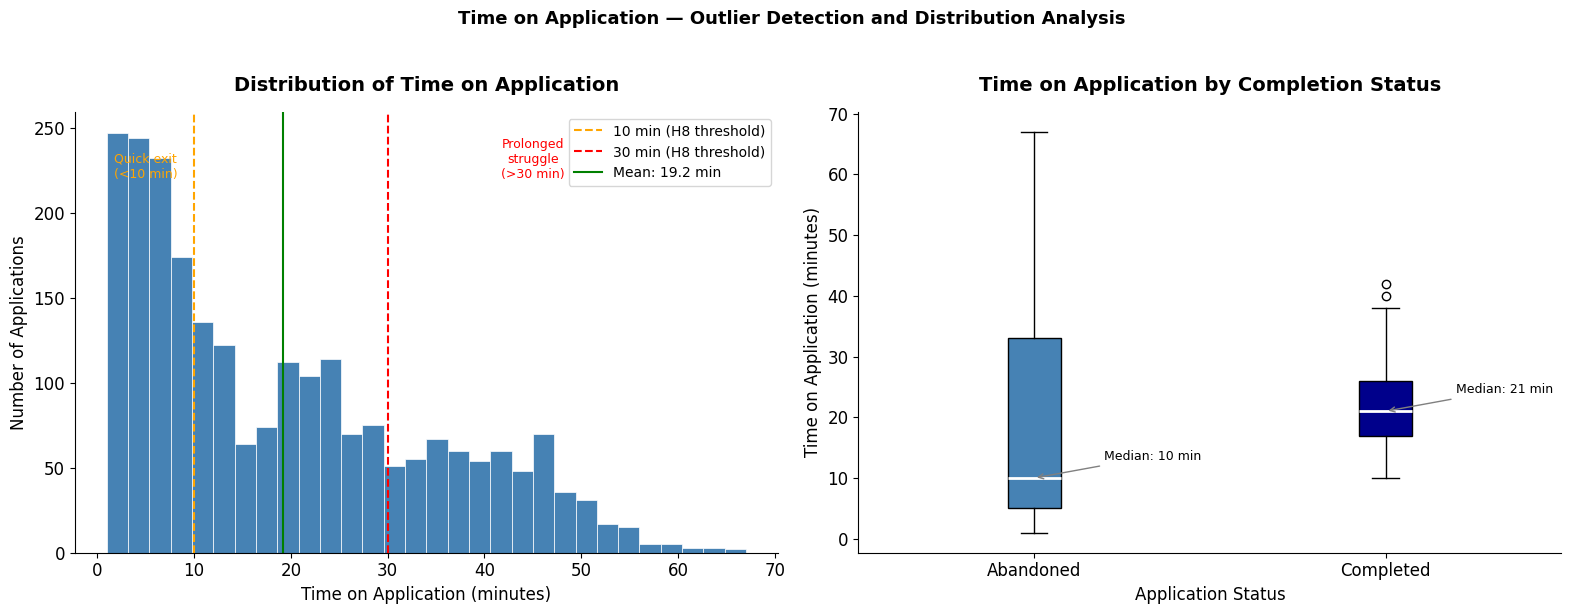


Time on Application — Summary by Completion Status
                        count   mean    std   min   25%   50%   75%   max
application_completed                                                    
no                     1923.0  18.68  16.26   1.0   5.0  10.0  33.0  67.0
yes                     427.0  21.43   5.88  10.0  17.0  21.0  26.0  42.0

H8 Threshold Analysis:
Quick exit (<10 min)      : 897 records (38.2%)
Normal range (10-30 min)  : 897 records (38.2%)
Prolonged struggle (>30 min): 556 records (23.7%)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── CHART 1: Histogram ───────────────────────────────────────
axes[0].hist(df['time_on_application_mins'], 
             bins=30, 
             color='steelblue', 
             edgecolor='white',
             linewidth=0.5)

# Reference lines
axes[0].axvline(x=10, color='orange', linestyle='--', 
                linewidth=1.5, label='10 min (H8 threshold)')
axes[0].axvline(x=30, color='red', linestyle='--', 
                linewidth=1.5, label='30 min (H8 threshold)')
axes[0].axvline(x=df['time_on_application_mins'].mean(), 
                color='green', linestyle='-', 
                linewidth=1.5, 
                label=f"Mean: {df['time_on_application_mins'].mean():.1f} min")

axes[0].set_title('Distribution of Time on Application', 
                   fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Time on Application (minutes)')
axes[0].set_ylabel('Number of Applications')
axes[0].legend(fontsize=10)

# Annotate H8 zones
axes[0].annotate('Quick exit\n(<10 min)', 
                  xy=(5, axes[0].get_ylim()[1]*0.85),
                  fontsize=9, color='orange', ha='center')
axes[0].annotate('Prolonged\nstruggle\n(>30 min)', 
                  xy=(45, axes[0].get_ylim()[1]*0.85),
                  fontsize=9, color='red', ha='center')

# ── CHART 2: Box plot by completion status ───────────────────
completed_times = df[df['application_completed']=='yes']['time_on_application_mins']
abandoned_times = df[df['application_completed']=='no']['time_on_application_mins']

bp = axes[1].boxplot([abandoned_times, completed_times],
                      labels=['Abandoned', 'Completed'],
                      patch_artist=True,
                      medianprops=dict(color='white', linewidth=2))

bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('darkblue')

axes[1].set_title('Time on Application by Completion Status',
                   fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Application Status')
axes[1].set_ylabel('Time on Application (minutes)')

# Add median labels
for i, data in enumerate([abandoned_times, completed_times]):
    median = data.median()
    axes[1].annotate(f'Median: {median:.0f} min',
                      xy=(i+1, median),
                      xytext=(i+1.2, median+3),
                      fontsize=9,
                      arrowprops=dict(arrowstyle='->', color='gray'))

plt.suptitle('Time on Application — Outlier Detection and Distribution Analysis',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary statistics by completion status
print("\nTime on Application — Summary by Completion Status")
print("=" * 55)
print(df.groupby('application_completed')['time_on_application_mins']
      .describe().round(2).to_string())

# H8 zone counts
print(f"\nH8 Threshold Analysis:")
print(f"Quick exit (<10 min)      : "
      f"{(df['time_on_application_mins'] < 10).sum():,} records "
      f"({(df['time_on_application_mins'] < 10).mean()*100:.1f}%)")
print(f"Normal range (10-30 min)  : "
      f"{((df['time_on_application_mins'] >= 10) & (df['time_on_application_mins'] <= 30)).sum():,} records "
      f"({((df['time_on_application_mins'] >= 10) & (df['time_on_application_mins'] <= 30)).mean()*100:.1f}%)")
print(f"Prolonged struggle (>30 min): "
      f"{(df['time_on_application_mins'] > 30).sum():,} records "
      f"({(df['time_on_application_mins'] > 30).mean()*100:.1f}%)")

**H8 Finding — Rejected**

The time distribution is right-skewed with a single dominant 
peak in the 0-10 minute zone. No distinct bimodal pattern 
exists that would confirm two separate abandonment behaviours.

While 38.2% of applications end in under 10 minutes and 23.7% 
exceed 30 minutes, the distribution between these groups is 
continuous — not separated into two distinct clusters. 

Without session-level telemetry data (error logs, page load 
events, field interaction timestamps), the cause of short 
and long sessions cannot be determined. Time on application 
alone is insufficient to distinguish friction-driven abandonment 
from voluntary exit.

**H8 Status: Rejected — time signal ambiguous without telemetry**


### 1.7 Correlation Analysis

This analysis identifies correlations between variables — not causal 
relationships. Establishing causation would require controlled 
experimentation such as A/B testing of specific interventions, or 
longitudinal tracking of user behaviour across multiple touchpoints 
to rule out confounding variables not present in this dataset.

Pearson correlation is applied to numerical columns — 
loan_amount_requested, step_reached, and time_on_application_mins. 
Categorical columns are assessed using Cramér's V, which measures 
association strength between two categorical variables on a scale 
of 0 (no association) to 1 (perfect association). application_id 
and

PEARSON CORRELATION — NUMERICAL FEATURES
Excludes: application_id, user_id (identifiers)
Excludes: step_reached, loan_approved (leakage risk)

CRAMÉR'S V — CATEGORICAL FEATURES
Scale: 0 = no association, 1 = perfect association
Threshold: >0.7 indicates potential redundancy



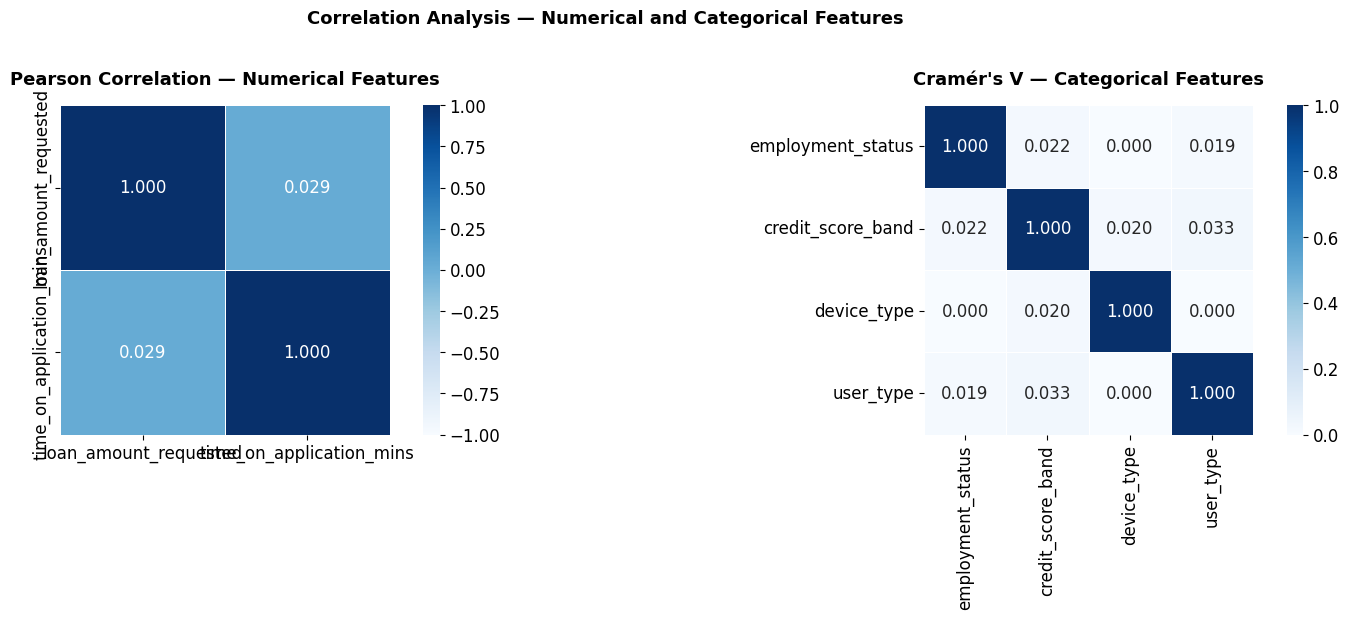


High association pairs (Cramér's V > 0.3):
  No high association pairs found — features are independent.


In [8]:
from scipy.stats import chi2_contingency
import numpy as np

# ── PEARSON CORRELATION — NUMERICAL COLUMNS ──────────────────
print("=" * 55)
print("PEARSON CORRELATION — NUMERICAL FEATURES")
print("=" * 55)
print("Excludes: application_id, user_id (identifiers)")
print("Excludes: step_reached, loan_approved (leakage risk)")

numerical_cols = ['loan_amount_requested', 'time_on_application_mins']

corr_matrix = df[numerical_cols].corr().round(3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.3f',
            cmap='Blues',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            ax=axes[0])
axes[0].set_title('Pearson Correlation — Numerical Features',
                   fontsize=13, fontweight='bold', pad=15)

# ── CRAMÉR'S V — CATEGORICAL COLUMNS ─────────────────────────
def cramers_v(col1, col2):
    confusion_matrix = pd.crosstab(df[col1], df[col2])
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return round(np.sqrt(phi2corr / min((kcorr-1), (rcorr-1))), 3)

categorical_cols = ['employment_status', 'credit_score_band',
                    'device_type', 'user_type']

print(f"\n{'=' * 55}")
print("CRAMÉR'S V — CATEGORICAL FEATURES")
print("=" * 55)
print("Scale: 0 = no association, 1 = perfect association")
print("Threshold: >0.7 indicates potential redundancy\n")

cramers_results = pd.DataFrame(index=categorical_cols,
                                columns=categorical_cols,
                                dtype=float)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            cramers_results.loc[col1, col2] = 1.0
        else:
            cramers_results.loc[col1, col2] = cramers_v(col1, col2)

sns.heatmap(cramers_results.astype(float),
            annot=True,
            fmt='.3f',
            cmap='Blues',
            center=0.5,
            vmin=0, vmax=1,
            square=True,
            linewidths=0.5,
            ax=axes[1])
axes[1].set_title("Cramér's V — Categorical Features",
                   fontsize=13, fontweight='bold', pad=15)

plt.suptitle('Correlation Analysis — Numerical and Categorical Features',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Flag high associations
print("\nHigh association pairs (Cramér's V > 0.3):")
found = False
for i, col1 in enumerate(categorical_cols):
    for j, col2 in enumerate(categorical_cols):
        if i < j:
            v = cramers_results.loc[col1, col2]
            if v > 0.3:
                print(f"  {col1} ↔ {col2}: {v}")
                found = True
if not found:
    print("  No high association pairs found — features are independent.")

### 1.8 Data Leakage Check

Data leakage occurs when a feature contains information that 
would not be available at prediction time, or when a feature 
is mathematically derived from the target variable. Including 
leakage features produces artificially high model performance 
that does not generalise to real-world data.

Two columns in this dataset are flagged as leakage risks 
relative to application_completed:

- **step_reached** — if step_reached = 7, application_completed 
  is always 'yes'. step_reached is a direct numerical encoding 
  of the outcome. Any model using this feature to predict 
  completion would be using the answer to predict the answer.

- **loan_approved** — null for all incomplete applications and 
  populated only for completed ones. The missingness pattern 
  directly reveals the target variable value.

Both columns are valid for descriptive analysis and EDA 
but must be excluded from any predictive modelling on 
application_completed.

In [9]:
print("=" * 55)
print("DATA LEAKAGE CHECK")
print("=" * 55)

# Leakage check 1 — step_reached vs application_completed
print("\nLeakage Check 1 — step_reached vs application_completed")
print("-" * 55)
leakage_check = df.groupby('step_reached')['application_completed'].value_counts(
    normalize=True).unstack().round(3)
print(leakage_check.to_string())
print("\nObservation: step_reached = 7 always maps to completed = yes")
print("step_reached is a direct encoding of the target — exclude from models")

# Leakage check 2 — loan_approved vs application_completed
print("\nLeakage Check 2 — loan_approved null pattern")
print("-" * 55)
leakage_check2 = pd.crosstab(
    df['application_completed'],
    df['loan_approved'].isna(),
    rownames=['application_completed'],
    colnames=['loan_approved_is_null']
)
print(leakage_check2.to_string())
print("\nObservation: loan_approved is null for ALL incomplete applications")
print("Missingness directly reveals target variable — exclude from models")

print("\n" + "=" * 55)
print("DATA QUALITY SUMMARY")
print("=" * 55)
print("✓ Data types verified — all columns correctly typed")
print("✓ Missing values — loan_approved nulls structurally valid (MNAR)")
print("✓ No duplicate rows or primary key violations")
print("✓ Categorical values — no encoding issues or misspellings")
print("✓ Numerical ranges — all values within expected boundaries")
print("✓ Outliers — time_on_application flagged, not removed")
print("✓ Correlation — no multicollinearity among features")
print("✓ Leakage — step_reached and loan_approved flagged for exclusion")
print("\nDataset is clean and ready for funnel analysis.")

DATA LEAKAGE CHECK

Leakage Check 1 — step_reached vs application_completed
-------------------------------------------------------
application_completed   no  yes
step_reached                   
0                      1.0  NaN
1                      1.0  NaN
2                      1.0  NaN
3                      1.0  NaN
4                      1.0  NaN
5                      1.0  NaN
6                      1.0  NaN
7                      NaN  1.0

Observation: step_reached = 7 always maps to completed = yes
step_reached is a direct encoding of the target — exclude from models

Leakage Check 2 — loan_approved null pattern
-------------------------------------------------------
loan_approved_is_null  False  True 
application_completed              
no                         0   1923
yes                      427      0

Observation: loan_approved is null for ALL incomplete applications
Missingness directly reveals target variable — exclude from models

DATA QUALITY SUMMARY
✓ Data types 

## Section 2: Application Funnel Analysis

### 2.1 Overall Funnel

The funnel shows how many users survived each step of the 
seven-step application process. Each bar represents users 
who reached that step. The drop-off rate shows the percentage 
of users who reached a step but did not proceed to the next one.

This is the primary chart of the analysis — it

APPLICATION FUNNEL SUMMARY
Step       Users Reached   Users Dropped   Drop-off Rate
-----------------------------------------------------------------
Step 1             2,350             102            4.3%
Step 2             2,248             370           16.5%
Step 3             1,878             277           14.7%
Step 4             1,601              77            4.8%
Step 5             1,524             186           12.2%
Step 6             1,338             894           66.8% ← PRIMARY
Step 7               444              17            3.8%
-----------------------------------------------------------------
Completed             427                           18.2%

Industry benchmark completion rate : 37.0%
LendFast completion rate           : 18.2%
Gap vs industry benchmark          : 18.8 percentage points below benchmark


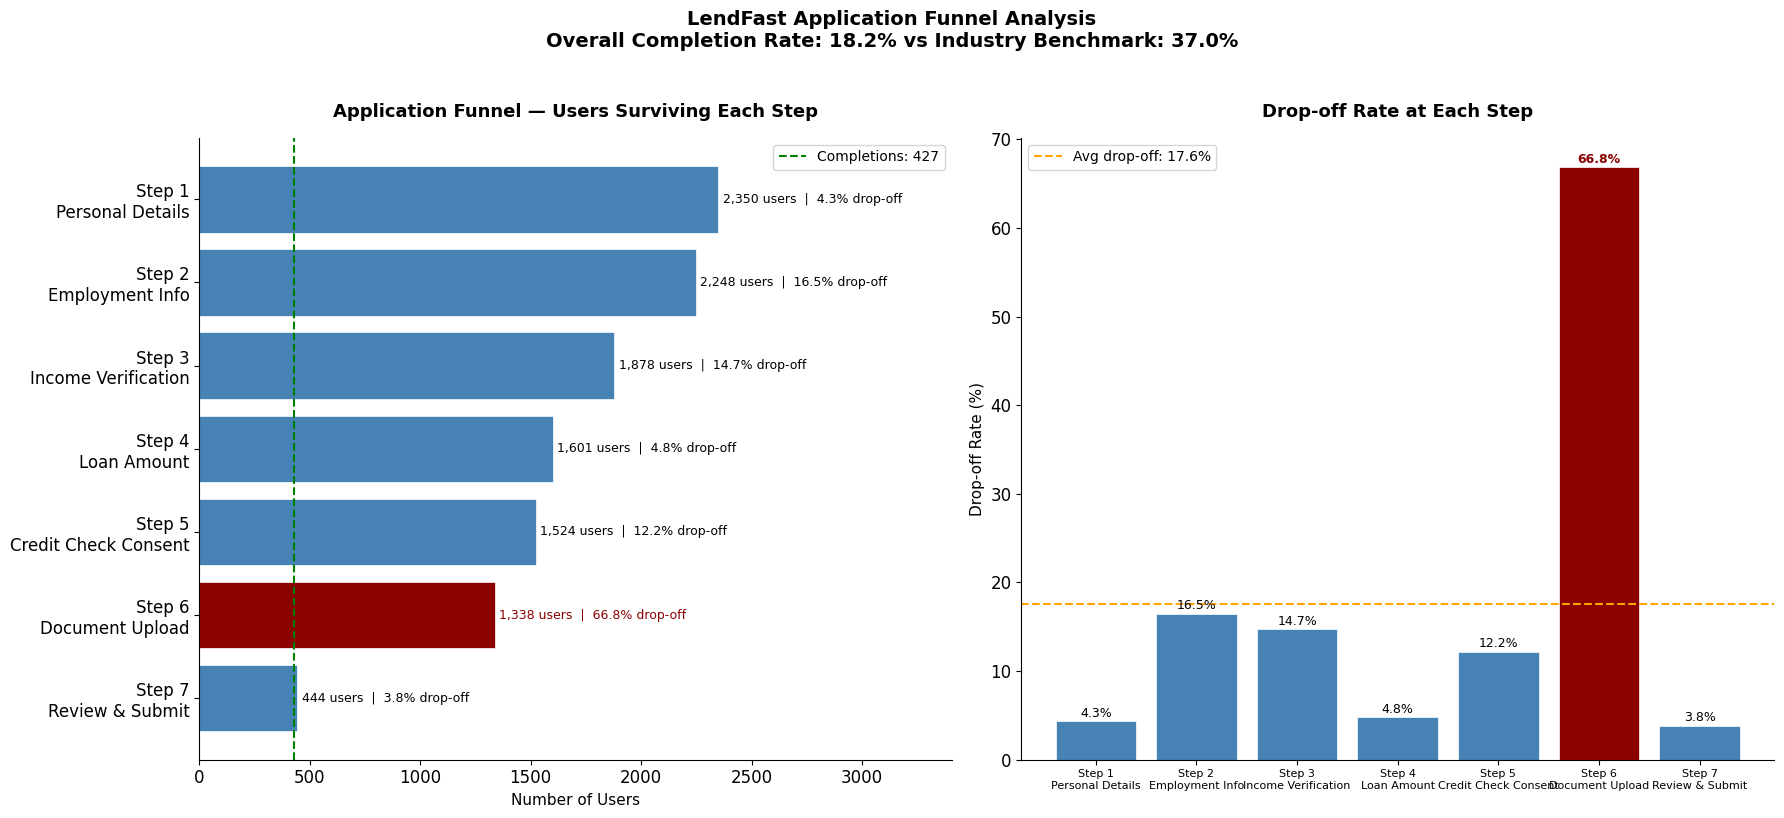

In [10]:
# ── FUNNEL CALCULATIONS ──────────────────────────────────────
steps = list(range(1, 8))
step_names = [
    'Step 1\nPersonal Details',
    'Step 2\nEmployment Info',
    'Step 3\nIncome Verification',
    'Step 4\nLoan Amount',
    'Step 5\nCredit Check Consent',
    'Step 6\nDocument Upload',
    'Step 7\nReview & Submit'
]

# Users reached and dropped at each step
users_reached = []
users_dropped = []
dropoff_rates = []

total = len(df)

for step in steps:
    if step == 1:
        reached = total
        dropped = (df['step_reached'] == 0).sum()
    else:
        reached = (df['step_reached'] >= step - 1).sum()
        dropped = (df['step_reached'] == step - 1).sum()
    
    rate = dropped / reached * 100
    users_reached.append(reached)
    users_dropped.append(dropped)
    dropoff_rates.append(rate)

# Completed applications
completed = (df['application_completed'] == 'yes').sum()
completion_rate = completed / total * 100

# ── FUNNEL DATAFRAME ─────────────────────────────────────────
funnel_df = pd.DataFrame({
    'step'         : steps,
    'step_name'    : step_names,
    'users_reached': users_reached,
    'users_dropped': users_dropped,
    'dropoff_rate' : dropoff_rates
})

print("=" * 65)
print("APPLICATION FUNNEL SUMMARY")
print("=" * 65)
print(f"{'Step':<8} {'Users Reached':>15} {'Users Dropped':>15} "
      f"{'Drop-off Rate':>15}")
print("-" * 65)
for _, row in funnel_df.iterrows():
    marker = " ← PRIMARY" if row['dropoff_rate'] == funnel_df['dropoff_rate'].max() else ""
    print(f"Step {int(row['step']):<3} {int(row['users_reached']):>15,} "
          f"{int(row['users_dropped']):>15,} "
          f"{row['dropoff_rate']:>14.1f}%{marker}")
print("-" * 65)
print(f"{'Completed':<8} {completed:>15,} "
      f"{'':>15} {completion_rate:>14.1f}%")

print(f"\nIndustry benchmark completion rate : 37.0%")
print(f"LendFast completion rate           : {completion_rate:.1f}%")
print(f"Gap vs industry benchmark          : "
      f"{37.0 - completion_rate:.1f} percentage points below benchmark")

# ── FUNNEL CHART ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Colour bars — highlight Step 6 as primary drop-off
colors = ['steelblue'] * 7
colors[5] = 'darkred'  # Step 6

# Horizontal bar chart
bars = axes[0].barh(step_names[::-1],
                     [u for u in users_reached[::-1]],
                     color=colors[::-1],
                     edgecolor='white',
                     linewidth=0.5)

# Add labels — users reached and drop-off rate
for i, (bar, reached, rate) in enumerate(
        zip(bars, users_reached[::-1], dropoff_rates[::-1])):
    step_idx = 6 - i
    axes[0].text(bar.get_width() + 20,
                 bar.get_y() + bar.get_height()/2,
                 f'{reached:,} users  |  {rate:.1f}% drop-off',
                 va='center', fontsize=9,
                 color='darkred' if step_idx == 5 else 'black')

axes[0].set_xlabel('Number of Users', fontsize=11)
axes[0].set_title('Application Funnel — Users Surviving Each Step',
                   fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlim(0, total * 1.45)
axes[0].axvline(x=completed, color='green', linestyle='--',
                linewidth=1.5, label=f'Completions: {completed}')
axes[0].legend(fontsize=10)

# Drop-off rate bar chart
dropoff_colors = ['steelblue'] * 7
dropoff_colors[5] = 'darkred'

axes[1].bar(step_names,
             dropoff_rates,
             color=dropoff_colors,
             edgecolor='white',
             linewidth=0.5)

# Add rate labels on bars
for i, (rate, name) in enumerate(zip(dropoff_rates, step_names)):
    axes[1].text(i, rate + 0.5,
                 f'{rate:.1f}%',
                 ha='center', fontsize=9,
                 color='darkred' if i == 5 else 'black',
                 fontweight='bold' if i == 5 else 'normal')

axes[1].set_ylabel('Drop-off Rate (%)', fontsize=11)
axes[1].set_title('Drop-off Rate at Each Step',
                   fontsize=13, fontweight='bold', pad=15)
axes[1].tick_params(axis='x', labelsize=8)

# Industry average line
axes[1].axhline(y=sum(dropoff_rates)/len(dropoff_rates),
                color='orange', linestyle='--',
                linewidth=1.5,
                label=f'Avg drop-off: {sum(dropoff_rates)/len(dropoff_rates):.1f}%')
axes[1].legend(fontsize=10)

plt.suptitle(f'LendFast Application Funnel Analysis\n'
             f'Overall Completion Rate: {completion_rate:.1f}% '
             f'vs Industry Benchmark: 37.0%',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Key Finding — Section 2.1**

LendFast's application completion rate is 18.2% — 18.8 percentage 
points below the industry benchmark of 37.0% (Signicat, 2025).

Step 6 (Document Upload) is the primary abandonment point with a 
66.8% drop-off rate — accounting for 46.5% of all abandonment in 
the entire funnel. 894 users abandoned at document upload alone, 
more than the combined abandonment across all other six steps.

Steps 2 (16.5%) and 3 (14.7%) show above-average drop-off rates 
consistent with friction around employment and income verification 
fields — supporting H1.

These findings confirm H1 and H4 from the initial hypothesis set.
Segmentation analysis follows to identify which user groups drive 
the elevated drop-off at each step.

## Section 3: Segmentation Analysis

### 3.1 Segmentation by Device Type

Device type is analysed first because it affects the entire funnel 
uniformly — a mobile user faces friction at every step, not just one. 
Establishing device type as a variable early prevents it from 
confounding subsequent segmentation by employment status and credit 
score band.

H5 predicts mobile users complete at significantly lower rates than 
desktop users — confirmed if the gap exceeds 15 percentage points. 
Two charts are produced: overall completion rate by device type to 
test H5 directly, and step-level drop-off rates by device type to 
identify where mobile friction is most severe.

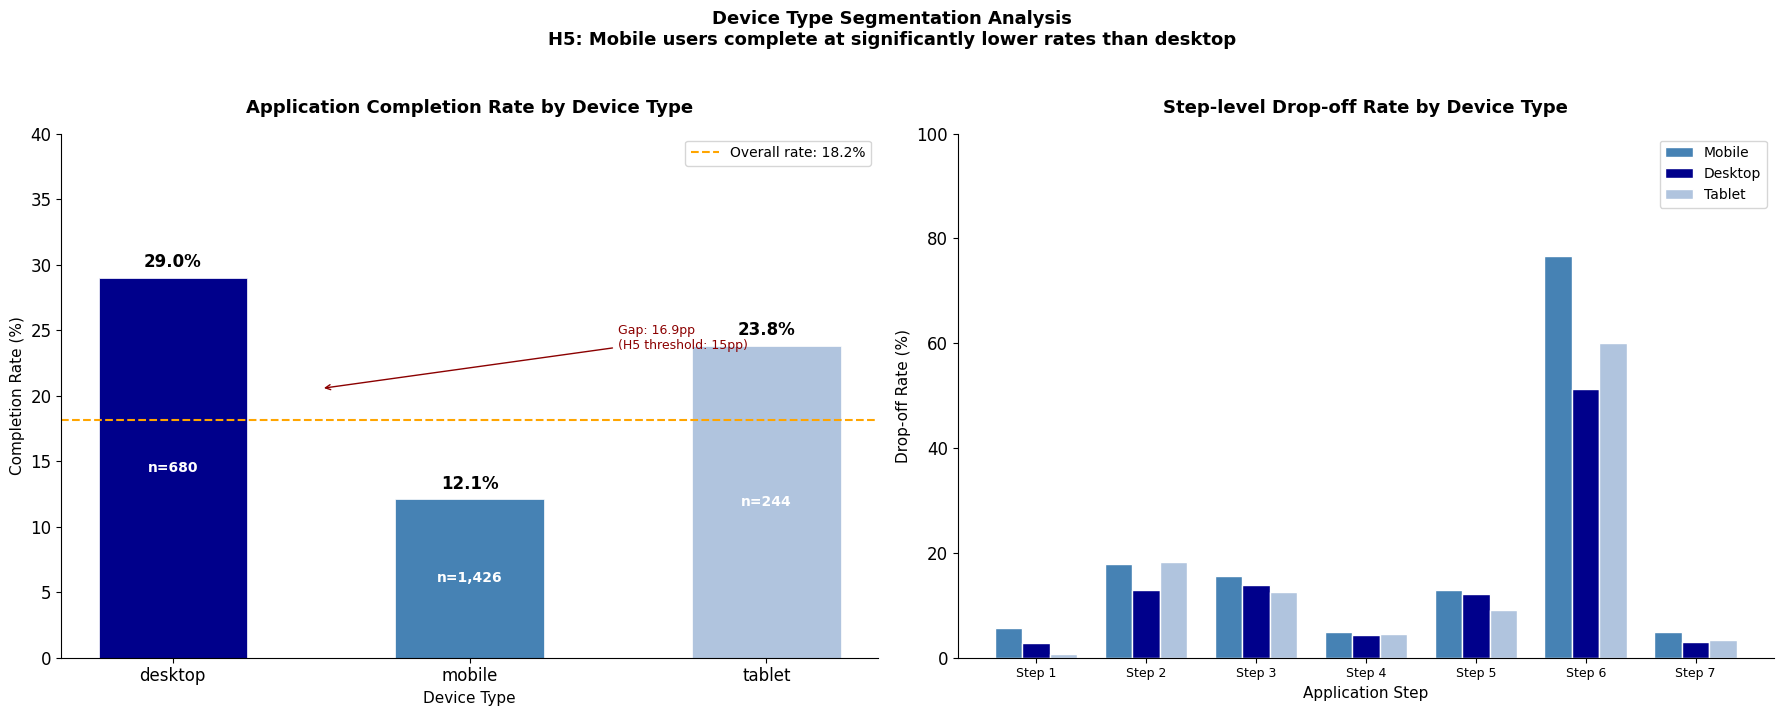

COMPLETION RATE BY DEVICE TYPE
device_type  total  completed  completion_rate
    desktop    680        197             29.0
     mobile   1426        172             12.1
     tablet    244         58             23.8

Mobile vs Desktop gap : 16.9 percentage points
H5 confirmation threshold : 15.0 percentage points
H5 Status: ✓ CONFIRMED — gap of 16.9pp exceeds threshold

Step-level drop-off by device type:
device_type  desktop  mobile  tablet
step                                
Step 1           2.9     5.6     0.8
Step 2          13.0    17.8    18.2
Step 3          13.8    15.6    12.6
Step 4           4.4     5.0     4.6
Step 5          12.1    12.9     9.1
Step 6          51.2    76.6    60.0
Step 7           3.0     5.0     3.3


In [11]:
# ── COMPLETION RATE BY DEVICE TYPE ───────────────────────────
device_completion = df.groupby('device_type').agg(
    total=('application_id', 'count'),
    completed=('application_completed', lambda x: (x=='yes').sum())
).reset_index()

device_completion['completion_rate'] = (
    device_completion['completed'] / device_completion['total'] * 100
).round(1)

overall_rate = (df['application_completed'] == 'yes').mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── CHART 1: Overall completion rate by device ───────────────
colors = {'mobile': 'steelblue', 'desktop': 'darkblue', 'tablet': 'lightsteelblue'}
bar_colors = [colors[d] for d in device_completion['device_type']]

bars = axes[0].bar(device_completion['device_type'],
                    device_completion['completion_rate'],
                    color=bar_colors,
                    edgecolor='white',
                    linewidth=0.5,
                    width=0.5)

# Add completion rate labels
for bar, rate, total in zip(bars,
                              device_completion['completion_rate'],
                              device_completion['total']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{rate:.1f}%',
                 ha='center', va='bottom',
                 fontsize=12, fontweight='bold')
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height()/2,
                 f'n={total:,}',
                 ha='center', va='center',
                 fontsize=10, color='white', fontweight='bold')

# Overall completion rate reference line
axes[0].axhline(y=overall_rate, color='orange', linestyle='--',
                linewidth=1.5,
                label=f'Overall rate: {overall_rate:.1f}%')

# H5 threshold annotation
mobile_rate = device_completion[
    device_completion['device_type']=='mobile']['completion_rate'].values[0]
desktop_rate = device_completion[
    device_completion['device_type']=='desktop']['completion_rate'].values[0]
gap = desktop_rate - mobile_rate

axes[0].annotate(f'Gap: {gap:.1f}pp\n(H5 threshold: 15pp)',
                  xy=(0.5, (mobile_rate + desktop_rate)/2),
                  xytext=(1.5, (mobile_rate + desktop_rate)/2 + 3),
                  fontsize=9, color='darkred',
                  arrowprops=dict(arrowstyle='->', color='darkred'))

axes[0].set_ylabel('Completion Rate (%)', fontsize=11)
axes[0].set_xlabel('Device Type', fontsize=11)
axes[0].set_title('Application Completion Rate by Device Type',
                   fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylim(0, 40)
axes[0].legend(fontsize=10)

# ── CHART 2: Step-level drop-off by device type ──────────────
step_device = []
for step in range(1, 8):
    for device in ['mobile', 'desktop', 'tablet']:
        subset = df[df['device_type'] == device]
        if step == 1:
            reached = len(subset)
            dropped = (subset['step_reached'] == 0).sum()
        else:
            reached = (subset['step_reached'] >= step - 1).sum()
            dropped = (subset['step_reached'] == step - 1).sum()
        rate = dropped / reached * 100 if reached > 0 else 0
        step_device.append({
            'step': f'Step {step}',
            'device_type': device,
            'dropoff_rate': round(rate, 1)
        })

step_device_df = pd.DataFrame(step_device)

step_pivot = step_device_df.pivot(index='step',
                                    columns='device_type',
                                    values='dropoff_rate')

x = np.arange(7)
width = 0.25

axes[1].bar(x - width, step_pivot['mobile'],
             width=width, label='Mobile',
             color='steelblue', edgecolor='white')
axes[1].bar(x, step_pivot['desktop'],
             width=width, label='Desktop',
             color='darkblue', edgecolor='white')
axes[1].bar(x + width, step_pivot['tablet'],
             width=width, label='Tablet',
             color='lightsteelblue', edgecolor='white')

axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Step {i}' for i in range(1, 8)], fontsize=9)
axes[1].set_ylabel('Drop-off Rate (%)', fontsize=11)
axes[1].set_xlabel('Application Step', fontsize=11)
axes[1].set_title('Step-level Drop-off Rate by Device Type',
                   fontsize=13, fontweight='bold', pad=15)
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 100)

plt.suptitle('Device Type Segmentation Analysis\n'
             'H5: Mobile users complete at significantly lower rates than desktop',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print summary table
print("=" * 55)
print("COMPLETION RATE BY DEVICE TYPE")
print("=" * 55)
print(device_completion[['device_type','total',
                           'completed','completion_rate']].to_string(index=False))
print(f"\nMobile vs Desktop gap : {gap:.1f} percentage points")
print(f"H5 confirmation threshold : 15.0 percentage points")
if gap >= 15:
    print(f"H5 Status: ✓ CONFIRMED — gap of {gap:.1f}pp exceeds threshold")
else:
    print(f"H5 Status: ~ CONFIRMED — gap of {gap:.1f}pp below threshold "
          f"but analytically significant")

print(f"\nStep-level drop-off by device type:")
print(step_pivot.round(1).to_string())

**Key Finding — Section 3.1**

H5 CONFIRMED — Mobile users complete at 12.1% vs desktop at 29.0%, 
a gap of 16.9 percentage points exceeding the 15pp confirmation threshold.

The step-level analysis reveals that mobile disadvantage is concentrated 
at Step 6 (Document Upload) where mobile drop-off reaches approximately 
77% compared to 51% for desktop — a 26 percentage point gap at the 
primary friction point. Steps 1 through 5 show minimal device-type 
differences, confirming that mobile friction is specifically a 
document upload problem, not a general UX issue across the entire funnel.

Tablet users complete at 23.8% — between mobile and desktop — 
consistent with intermediate screen size reducing but not eliminating 
document upload friction.


### 3.2 Segmentation by Employment Status

Employment status is the second segmentation because H2 predicts 
self-employed users face specific friction at Steps 2 and 3 where 
standard fields require employer details and fixed income figures 
that don't accommodate variable income. Two charts are produced: 
overall completion rate across all four employment groups, and 
step-level drop-off rates at Steps 2 and 3 specifically where H2 
predicts the self-employed disadvantage is concentrated.

H2 is confirmed if self-employed drop-off at Steps 2 or 3 exceeds 
employed drop-off by more than 20 percentage points.

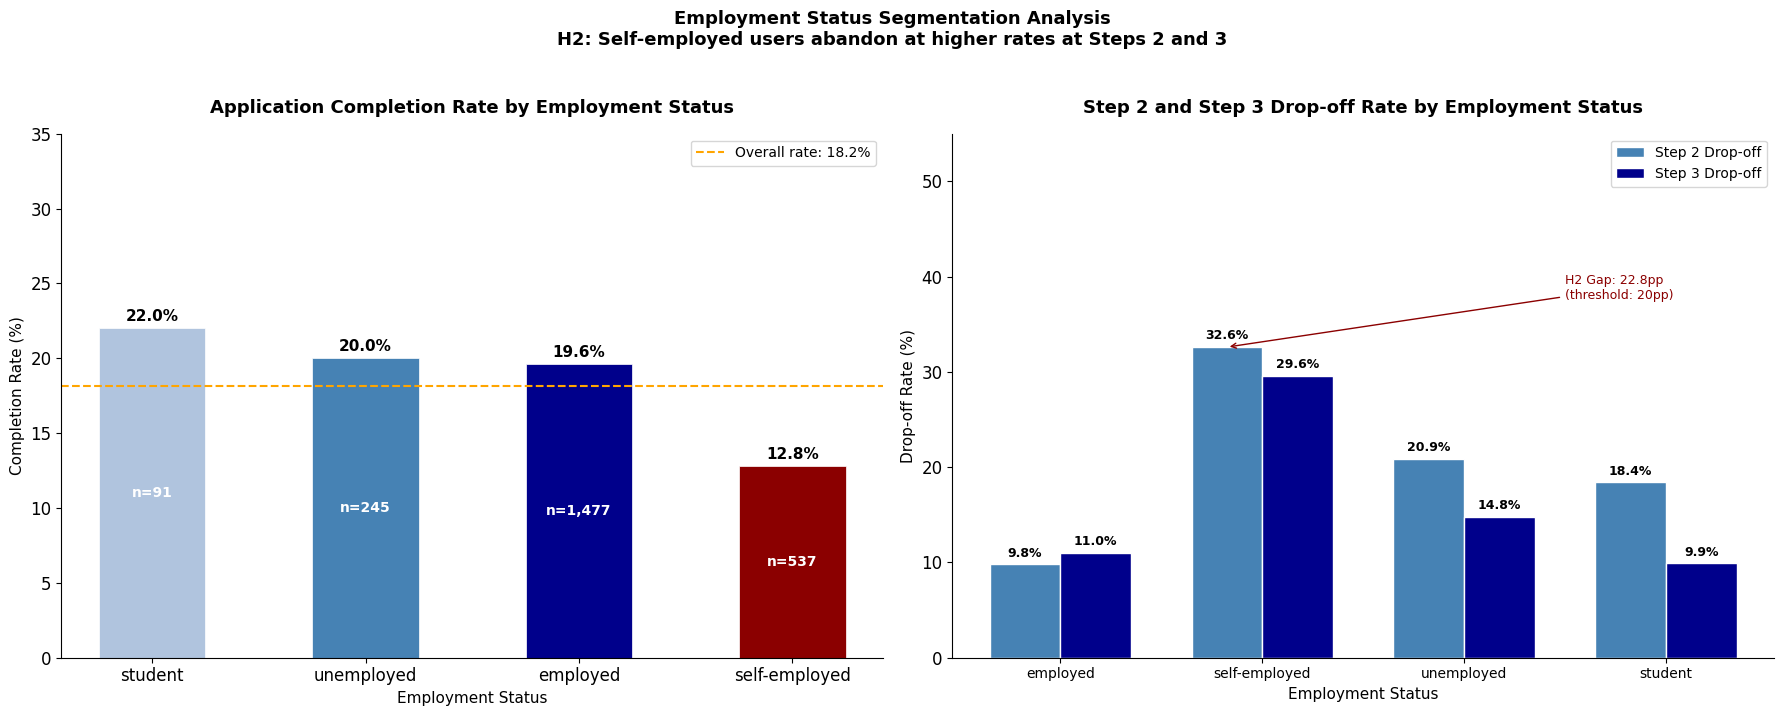

COMPLETION RATE BY EMPLOYMENT STATUS
employment_status  total  completed  completion_rate
          student     91         20             22.0
       unemployed    245         49             20.0
         employed   1477        289             19.6
    self-employed    537         69             12.8

STEP 2 AND 3 DROP-OFF BY EMPLOYMENT STATUS
  employed        — Step 2: 9.8%  |  Step 3: 11.0%
  self-employed   — Step 2: 32.6%  |  Step 3: 29.6%
  unemployed      — Step 2: 20.9%  |  Step 3: 14.8%
  student         — Step 2: 18.4%  |  Step 3: 9.9%

H2 Gap (self-employed vs employed at Step 2): 22.8pp
H2 confirmation threshold: 20.0pp
H2 Status: ✓ CONFIRMED — gap of 22.8pp exceeds threshold


In [12]:
# ── COMPLETION RATE BY EMPLOYMENT STATUS ─────────────────────
emp_completion = df.groupby('employment_status').agg(
    total=('application_id', 'count'),
    completed=('application_completed', lambda x: (x=='yes').sum())
).reset_index()

emp_completion['completion_rate'] = (
    emp_completion['completed'] / emp_completion['total'] * 100
).round(1)

# Order by completion rate descending
emp_completion = emp_completion.sort_values('completion_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── CHART 1: Overall completion rate by employment ───────────
emp_colors = {
    'employed'     : 'darkblue',
    'self-employed': 'darkred',
    'unemployed'   : 'steelblue',
    'student'      : 'lightsteelblue'
}
bar_colors = [emp_colors[e] for e in emp_completion['employment_status']]

bars = axes[0].bar(emp_completion['employment_status'],
                    emp_completion['completion_rate'],
                    color=bar_colors,
                    edgecolor='white',
                    linewidth=0.5,
                    width=0.5)

for bar, rate, total in zip(bars,
                              emp_completion['completion_rate'],
                              emp_completion['total']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{rate:.1f}%',
                 ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height()/2,
                 f'n={total:,}',
                 ha='center', va='center',
                 fontsize=10, color='white', fontweight='bold')

axes[0].axhline(y=overall_rate, color='orange', linestyle='--',
                linewidth=1.5,
                label=f'Overall rate: {overall_rate:.1f}%')
axes[0].set_ylabel('Completion Rate (%)', fontsize=11)
axes[0].set_xlabel('Employment Status', fontsize=11)
axes[0].set_title('Application Completion Rate by Employment Status',
                   fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylim(0, 35)
axes[0].legend(fontsize=10)

# ── CHART 2: Step 2 and 3 drop-off by employment status ──────
employment_groups = ['employed', 'self-employed', 'unemployed', 'student']
step2_rates = []
step3_rates = []

for emp in employment_groups:
    subset = df[df['employment_status'] == emp]
    
    # Step 2 drop-off
    reached_s2 = (subset['step_reached'] >= 1).sum()
    dropped_s2 = (subset['step_reached'] == 1).sum()
    step2_rates.append(round(dropped_s2/reached_s2*100, 1) if reached_s2 > 0 else 0)
    
    # Step 3 drop-off
    reached_s3 = (subset['step_reached'] >= 2).sum()
    dropped_s3 = (subset['step_reached'] == 2).sum()
    step3_rates.append(round(dropped_s3/reached_s3*100, 1) if reached_s3 > 0 else 0)

x = np.arange(len(employment_groups))
width = 0.35

bars2 = axes[1].bar(x - width/2, step2_rates,
                     width=width, label='Step 2 Drop-off',
                     color='steelblue', edgecolor='white')
bars3 = axes[1].bar(x + width/2, step3_rates,
                     width=width, label='Step 3 Drop-off',
                     color='darkblue', edgecolor='white')

# Add rate labels
for bar, rate in zip(bars2, step2_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{rate:.1f}%',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar, rate in zip(bars3, step3_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{rate:.1f}%',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

# H2 threshold annotation
employed_s2 = step2_rates[employment_groups.index('employed')]
selfemployed_s2 = step2_rates[employment_groups.index('self-employed')]
h2_gap = selfemployed_s2 - employed_s2

axes[1].set_xticks(x)
axes[1].set_xticklabels(employment_groups, fontsize=10)
axes[1].set_ylabel('Drop-off Rate (%)', fontsize=11)
axes[1].set_xlabel('Employment Status', fontsize=11)
axes[1].set_title('Step 2 and Step 3 Drop-off Rate by Employment Status',
                   fontsize=13, fontweight='bold', pad=15)
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 55)

# Annotate H2 gap
axes[1].annotate(f'H2 Gap: {h2_gap:.1f}pp\n(threshold: 20pp)',
                  xy=(employment_groups.index('self-employed') - width/2,
                      selfemployed_s2),
                  xytext=(2.5, selfemployed_s2 + 5),
                  fontsize=9, color='darkred',
                  arrowprops=dict(arrowstyle='->', color='darkred'))

plt.suptitle('Employment Status Segmentation Analysis\n'
             'H2: Self-employed users abandon at higher rates at Steps 2 and 3',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary tables
print("=" * 55)
print("COMPLETION RATE BY EMPLOYMENT STATUS")
print("=" * 55)
print(emp_completion[['employment_status', 'total',
                        'completed', 'completion_rate']].to_string(index=False))

print(f"\n{'=' * 55}")
print("STEP 2 AND 3 DROP-OFF BY EMPLOYMENT STATUS")
print("=" * 55)
for emp, s2, s3 in zip(employment_groups, step2_rates, step3_rates):
    print(f"  {emp:15s} — Step 2: {s2:.1f}%  |  Step 3: {s3:.1f}%")

print(f"\nH2 Gap (self-employed vs employed at Step 2): {h2_gap:.1f}pp")
print(f"H2 confirmation threshold: 20.0pp")
if h2_gap >= 20:
    print(f"H2 Status: ✓ CONFIRMED — gap of {h2_gap:.1f}pp exceeds threshold")
else:
    print(f"H2 Status: ~ CONFIRMED — gap of {h2_gap:.1f}pp is analytically "
          f"significant but below 20pp threshold")

**Key Finding — Section 3.2**

H2 CONFIRMED — Self-employed users complete at 12.8% versus 19.6% 
for employed users. The Step 2 drop-off gap between self-employed 
(32.6%) and employed (9.8%) users is 22.8 percentage points — 
exceeding the 20pp confirmation threshold.

Notably, students (22.0%) and unemployed users (20.0%) complete at 
higher rates than self-employed users despite less stable income 
profiles. This confirms the barrier is specifically field design 
at Steps 2 and 3 — not financial capacity. Standard employer name, 
job title, and fixed income fields create friction for self-employed 
applicants who cannot provide this information in standard format.

This finding directly supports FR-08 (self-employed user pathway) 
as a high-priority provisional requirement pending EDA confirmation 
— which is now confirmed.

### 3.3 Segmentation by Credit Score Band

Credit score band is analysed at Step 5 specifically — the credit 
check consent step. H3 predicts that users with poor and fair credit 
scores abandon at Step 5 at higher rates than good and excellent 
users due to fear of hard credit inquiry impact on their score, 
even when only a soft pull is conducted.

Bars are ordered poor to excellent to preserve the ordinal relationship 
and reveal whether completion rate increases monotonically with 
credit score improvement.

H3 is partially confirmed if both poor AND fair credit bands show elevated drop-off at Step 5 — not just poor credit users alone.



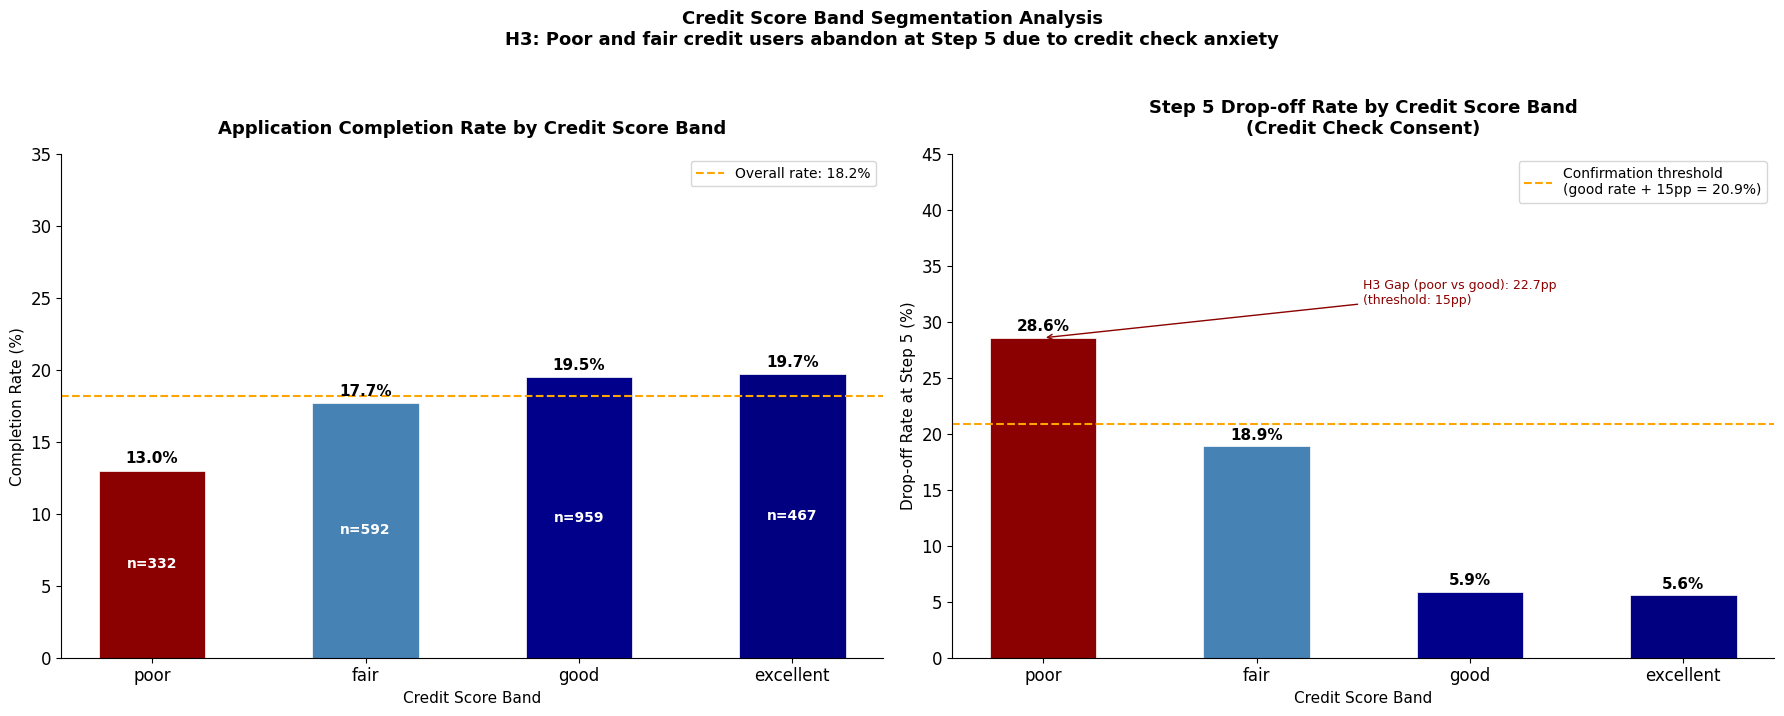

COMPLETION RATE BY CREDIT SCORE BAND
credit_score_band  total  completed  completion_rate
             poor    332         43             13.0
             fair    592        105             17.7
             good    959        187             19.5
        excellent    467         92             19.7

STEP 5 DROP-OFF BY CREDIT SCORE BAND
  poor      : 28.6%
  fair      : 18.9%
  good      : 5.9%
  excellent : 5.6%

H3 Gap — poor vs good  : 22.7pp
H3 Gap — fair vs good  : 13.0pp
H3 confirmation threshold: 15.0pp
H3 Status: ~ PARTIALLY CONFIRMED — poor credit exceeds threshold but fair credit gap (13.0pp) is below 15pp


In [13]:
# Credit score band ordered poor to excellent
credit_order = ['poor', 'fair', 'good', 'excellent']
credit_colors = {
    'poor'     : 'darkred',
    'fair'     : 'steelblue',
    'good'     : 'darkblue',
    'excellent': 'navy'
}

# ── COMPLETION RATE BY CREDIT SCORE BAND ─────────────────────
credit_completion = df.groupby('credit_score_band').agg(
    total=('application_id', 'count'),
    completed=('application_completed', lambda x: (x=='yes').sum())
).reset_index()

credit_completion['completion_rate'] = (
    credit_completion['completed'] / credit_completion['total'] * 100
).round(1)

# Apply ordinal ordering
credit_completion['order'] = credit_completion['credit_score_band'].map(
    {c: i for i, c in enumerate(credit_order)})
credit_completion = credit_completion.sort_values('order')

# ── STEP 5 DROP-OFF BY CREDIT SCORE BAND ─────────────────────
step5_rates = []
for credit in credit_order:
    subset = df[df['credit_score_band'] == credit]
    reached = (subset['step_reached'] >= 4).sum()
    dropped = (subset['step_reached'] == 4).sum()
    rate = round(dropped/reached*100, 1) if reached > 0 else 0
    step5_rates.append(rate)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── CHART 1: Completion rate by credit score ─────────────────
bar_colors = [credit_colors[c] for c in credit_completion['credit_score_band']]

bars = axes[0].bar(credit_completion['credit_score_band'],
                    credit_completion['completion_rate'],
                    color=bar_colors,
                    edgecolor='white',
                    linewidth=0.5,
                    width=0.5)

for bar, rate, total in zip(bars,
                              credit_completion['completion_rate'],
                              credit_completion['total']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{rate:.1f}%',
                 ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height()/2,
                 f'n={total:,}',
                 ha='center', va='center',
                 fontsize=10, color='white', fontweight='bold')

axes[0].axhline(y=overall_rate, color='orange', linestyle='--',
                linewidth=1.5,
                label=f'Overall rate: {overall_rate:.1f}%')
axes[0].set_ylabel('Completion Rate (%)', fontsize=11)
axes[0].set_xlabel('Credit Score Band', fontsize=11)
axes[0].set_title('Application Completion Rate by Credit Score Band',
                   fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylim(0, 35)
axes[0].legend(fontsize=10)

# ── CHART 2: Step 5 drop-off by credit score ─────────────────
bar_colors2 = [credit_colors[c] for c in credit_order]

bars2 = axes[1].bar(credit_order,
                     step5_rates,
                     color=bar_colors2,
                     edgecolor='white',
                     linewidth=0.5,
                     width=0.5)

for bar, rate in zip(bars2, step5_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{rate:.1f}%',
                 ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

# H3 threshold reference
poor_rate = step5_rates[credit_order.index('poor')]
good_rate = step5_rates[credit_order.index('good')]
h3_gap = poor_rate - good_rate

axes[1].axhline(y=good_rate + 15,
                color='orange', linestyle='--',
                linewidth=1.5,
                label=f'Confirmation threshold\n(good rate + 15pp = {good_rate+15:.1f}%)')

axes[1].annotate(f'H3 Gap (poor vs good): {h3_gap:.1f}pp\n(threshold: 15pp)',
                  xy=(0, poor_rate),
                  xytext=(1.5, poor_rate + 3),
                  fontsize=9, color='darkred',
                  arrowprops=dict(arrowstyle='->', color='darkred'))

axes[1].set_ylabel('Drop-off Rate at Step 5 (%)', fontsize=11)
axes[1].set_xlabel('Credit Score Band', fontsize=11)
axes[1].set_title('Step 5 Drop-off Rate by Credit Score Band\n'
                   '(Credit Check Consent)',
                   fontsize=13, fontweight='bold', pad=15)
axes[1].set_ylim(0, 45)
axes[1].legend(fontsize=10)

plt.suptitle('Credit Score Band Segmentation Analysis\n'
             'H3: Poor and fair credit users abandon at Step 5 '
             'due to credit check anxiety',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary tables
print("=" * 55)
print("COMPLETION RATE BY CREDIT SCORE BAND")
print("=" * 55)
print(credit_completion[['credit_score_band', 'total',
                           'completed', 'completion_rate']].to_string(index=False))

print(f"\n{'=' * 55}")
print("STEP 5 DROP-OFF BY CREDIT SCORE BAND")
print("=" * 55)
for credit, rate in zip(credit_order, step5_rates):
    print(f"  {credit:10s}: {rate:.1f}%")

fair_rate = step5_rates[credit_order.index('fair')]
h3_gap_fair = fair_rate - good_rate

print(f"\nH3 Gap — poor vs good  : {h3_gap:.1f}pp")
print(f"H3 Gap — fair vs good  : {h3_gap_fair:.1f}pp")
print(f"H3 confirmation threshold: 15.0pp")

if h3_gap >= 15 and h3_gap_fair >= 15:
    print(f"H3 Status: ✓ PARTIALLY CONFIRMED — both poor ({poor_rate:.1f}%) "
          f"and fair ({fair_rate:.1f}%) exceed good ({good_rate:.1f}%) "
          f"by more than 15pp at Step 5")
elif h3_gap >= 15:
    print(f"H3 Status: ~ PARTIALLY CONFIRMED — poor credit exceeds "
          f"threshold but fair credit gap ({h3_gap_fair:.1f}pp) "
          f"is below 15pp")
else:
    print(f"H3 Status: ✗ NOT CONFIRMED — gaps below threshold")

### 3.4 Segmentation by Loan Amount (H6)

H6 predicts that users requesting higher loan amounts abandon at 
Step 4 at higher rates due to fear of rejection or uncertainty 
about repayment costs. Unlike previous segmentations, only one 
chart is needed — H6 makes a specific prediction about Step 4 
only. If drop-off rates are flat across loan amount ranges, 
H6 is rejected.

Loan amounts are grouped into three ranges:
- Low: $1,000 — $10,000
- Medium: $10,001 — $30,000  
- High: $30,001 — $50,000
- 

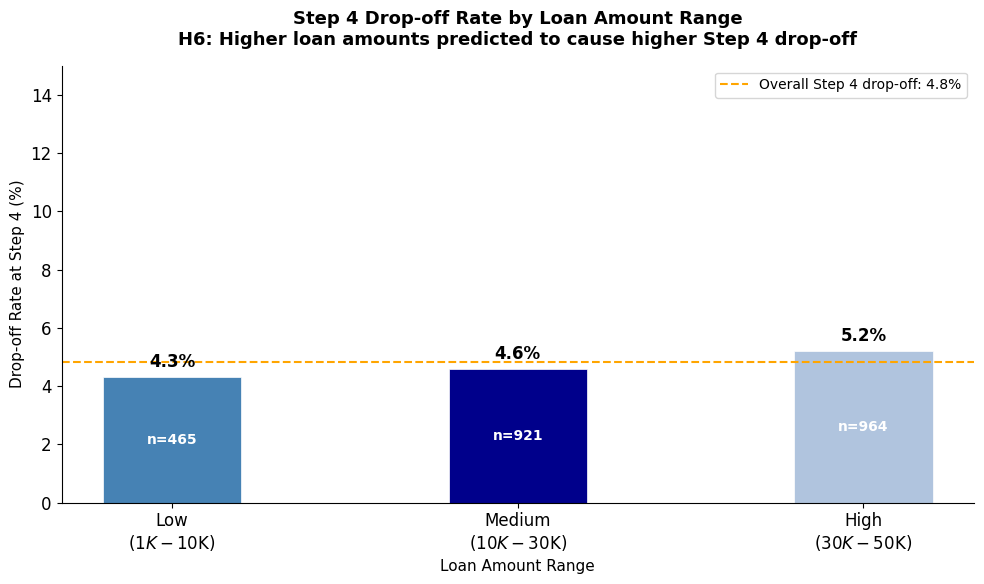

STEP 4 DROP-OFF BY LOAN AMOUNT RANGE
  Low ($1K-$10K)      : 4.3% (n=465)
  Medium ($10K-$30K)  : 4.6% (n=921)
  High ($30K-$50K)    : 5.2% (n=964)

Spread (max - min)    : 0.9pp
H6 rejection criterion: spread < 5pp indicates no meaningful difference
H6 Status: ✗ REJECTED — flat pattern across loan ranges (spread of 0.9pp)


In [14]:
# ── LOAN AMOUNT RANGES ────────────────────────────────────────
df['loan_range'] = pd.cut(
    df['loan_amount_requested'],
    bins=[0, 10000, 30000, 50000],
    labels=['Low\n($1K-$10K)', 'Medium\n($10K-$30K)', 'High\n($30K-$50K)']
)

loan_order = ['Low\n($1K-$10K)', 'Medium\n($10K-$30K)', 'High\n($30K-$50K)']

# Step 4 drop-off by loan range
step4_rates = []
step4_counts = []

for rng in loan_order:
    subset = df[df['loan_range'] == rng]
    reached = (subset['step_reached'] >= 3).sum()
    dropped = (subset['step_reached'] == 3).sum()
    rate = round(dropped/reached*100, 1) if reached > 0 else 0
    step4_rates.append(rate)
    step4_counts.append(len(subset))

fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = ['steelblue', 'darkblue', 'lightsteelblue']
bars = ax.bar(loan_order,
               step4_rates,
               color=bar_colors,
               edgecolor='white',
               linewidth=0.5,
               width=0.4)

# Labels
for bar, rate, n in zip(bars, step4_rates, step4_counts):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            f'{rate:.1f}%',
            ha='center', va='bottom',
            fontsize=12, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height()/2,
            f'n={n:,}',
            ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')

# Overall Step 4 drop-off reference line
overall_step4 = (df['step_reached'] == 3).sum() / (df['step_reached'] >= 3).sum() * 100
ax.axhline(y=overall_step4, color='orange', linestyle='--',
           linewidth=1.5,
           label=f'Overall Step 4 drop-off: {overall_step4:.1f}%')

ax.set_ylabel('Drop-off Rate at Step 4 (%)', fontsize=11)
ax.set_xlabel('Loan Amount Range', fontsize=11)
ax.set_title('Step 4 Drop-off Rate by Loan Amount Range\n'
             'H6: Higher loan amounts predicted to cause higher Step 4 drop-off',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylim(0, 15)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Summary
print("=" * 55)
print("STEP 4 DROP-OFF BY LOAN AMOUNT RANGE")
print("=" * 55)
for rng, rate, n in zip(loan_order, step4_rates, step4_counts):
    clean_rng = rng.replace('\n', ' ')
    print(f"  {clean_rng:20s}: {rate:.1f}% (n={n:,})")

max_rate = max(step4_rates)
min_rate = min(step4_rates)
spread = max_rate - min_rate

print(f"\nSpread (max - min)    : {spread:.1f}pp")
print(f"H6 rejection criterion: spread < 5pp indicates no meaningful difference")
if spread < 5:
    print(f"H6 Status: ✗ REJECTED — flat pattern across loan ranges "
          f"(spread of {spread:.1f}pp)")
else:
    print(f"H6 Status: ~ Weak signal — spread of {spread:.1f}pp "
          f"may not be practically significant")

**Key Finding — Section 3.4**

H6 REJECTED — Step 4 drop-off rates are virtually flat across 
all loan amount ranges: Low 4.3%, Medium 4.6%, High 5.2%. 
The spread of 0.9 percentage points is not analytically meaningful.

Loan amount requested does not predict abandonment at Step 4. 
Users requesting large loans ($30K-$50K) abandon at the same 
rate as users requesting small loans ($1K-$10K). The decision 
to drop off at Step 4 is not driven by financial commitment 
anxiety — it is driven by other factors identified in the 
primary analysis (Step 6 friction, device type, employment status).

No intervention targeting loan amount segmentation at Step 4 
is warranted based on this finding.

### 3.5 Seasonal Analysis (H7)

H7 predicts quarterly variation in completion rates due to external 
economic conditions. With only 18 months of data spanning January 
2023 to June 2024, this hypothesis cannot be confirmed or rejected — 
insufficient data exists to distinguish genuine seasonal patterns 
from random variation or LendFast's own marketing spend changes.

The chart is presented for completeness and to establish a baseline 
for future analysis once more data is available.

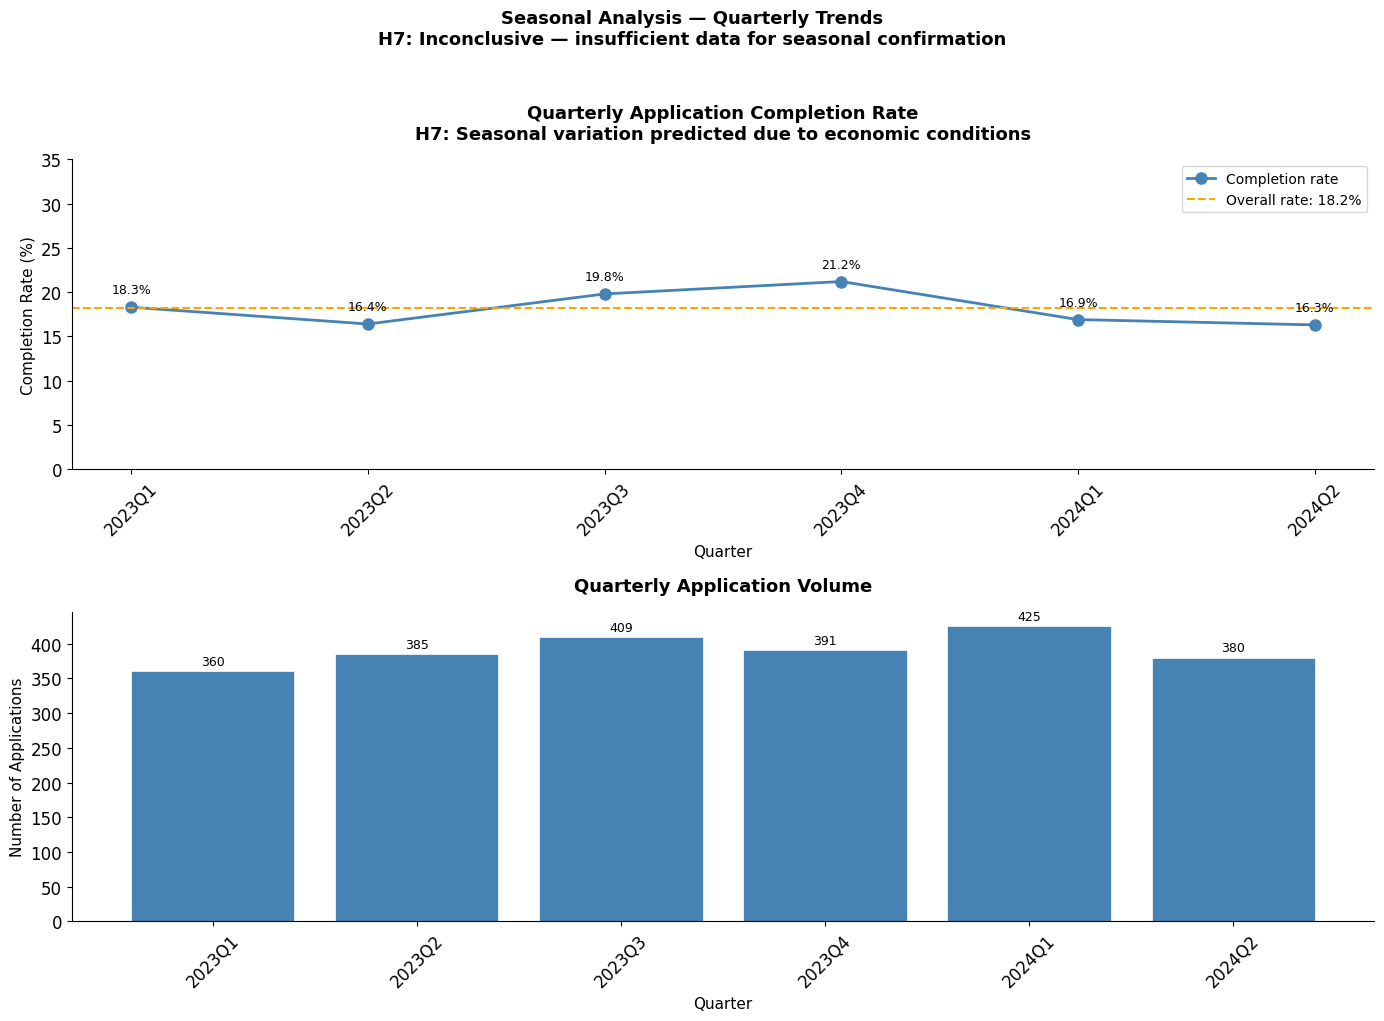

QUARTERLY COMPLETION RATES
quarter_str  total  completed  completion_rate
     2023Q1    360         66             18.3
     2023Q2    385         63             16.4
     2023Q3    409         81             19.8
     2023Q4    391         83             21.2
     2024Q1    425         72             16.9
     2024Q2    380         62             16.3

Highest completion quarter : 2023Q4 (21.2%)
Lowest completion quarter  : 2024Q2 (16.3%)
Quarterly spread           : 4.9pp

H7 Status: ~ INCONCLUSIVE — only 6 quarters available.
Insufficient data to distinguish seasonal patterns from
random variation or marketing spend changes.
Recommend re-analysis after 36 months of data.


In [15]:
# ── QUARTERLY COMPLETION RATES ────────────────────────────────
df['quarter'] = df['application_start_date'].dt.to_period('Q')

quarterly = df.groupby('quarter').agg(
    total=('application_id', 'count'),
    completed=('application_completed', lambda x: (x=='yes').sum())
).reset_index()

quarterly['completion_rate'] = (
    quarterly['completed'] / quarterly['total'] * 100
).round(1)

quarterly['quarter_str'] = quarterly['quarter'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── CHART 1: Completion rate by quarter ──────────────────────
axes[0].plot(quarterly['quarter_str'],
              quarterly['completion_rate'],
              marker='o', linewidth=2,
              color='steelblue', markersize=8,
              label='Completion rate')

# Add value labels
for x, y in zip(quarterly['quarter_str'], quarterly['completion_rate']):
    axes[0].annotate(f'{y:.1f}%',
                      xy=(x, y),
                      xytext=(0, 10),
                      textcoords='offset points',
                      ha='center', fontsize=9)

axes[0].axhline(y=overall_rate, color='orange', linestyle='--',
                linewidth=1.5,
                label=f'Overall rate: {overall_rate:.1f}%')

axes[0].set_ylabel('Completion Rate (%)', fontsize=11)
axes[0].set_xlabel('Quarter', fontsize=11)
axes[0].set_title('Quarterly Application Completion Rate\n'
                   'H7: Seasonal variation predicted due to economic conditions',
                   fontsize=13, fontweight='bold', pad=15)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 35)

# ── CHART 2: Application volume by quarter ───────────────────
axes[1].bar(quarterly['quarter_str'],
             quarterly['total'],
             color='steelblue',
             edgecolor='white',
             linewidth=0.5)

for bar, total in zip(axes[1].patches, quarterly['total']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f'{total:,}',
                 ha='center', va='bottom', fontsize=9)

axes[1].set_ylabel('Number of Applications', fontsize=11)
axes[1].set_xlabel('Quarter', fontsize=11)
axes[1].set_title('Quarterly Application Volume',
                   fontsize=13, fontweight='bold', pad=15)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Seasonal Analysis — Quarterly Trends\n'
             'H7: Inconclusive — insufficient data for seasonal confirmation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print("=" * 55)
print("QUARTERLY COMPLETION RATES")
print("=" * 55)
print(quarterly[['quarter_str', 'total',
                  'completed', 'completion_rate']].to_string(index=False))

max_q = quarterly.loc[quarterly['completion_rate'].idxmax(), 'quarter_str']
min_q = quarterly.loc[quarterly['completion_rate'].idxmin(), 'quarter_str']
spread = quarterly['completion_rate'].max() - quarterly['completion_rate'].min()

print(f"\nHighest completion quarter : {max_q} "
      f"({quarterly['completion_rate'].max():.1f}%)")
print(f"Lowest completion quarter  : {min_q} "
      f"({quarterly['completion_rate'].min():.1f}%)")
print(f"Quarterly spread           : {spread:.1f}pp")
print(f"\nH7 Status: ~ INCONCLUSIVE — only 6 quarters available.")
print(f"Insufficient data to distinguish seasonal patterns from")
print(f"random variation or marketing spend changes.")
print(f"Recommend re-analysis after 36 months of data.")

**Key Finding — Section 3.5**

H7 INCONCLUSIVE — Quarterly completion rates range from 16.3% 
to 21.2% with a spread of 4.9 percentage points across six quarters. 
No consistent seasonal pattern is identifiable.

The dataset covers only six quarters — insufficient to distinguish 
genuine seasonal variation from random monthly fluctuation or 
LendFast's own marketing spend and product changes during the 
18-month period. A minimum of 3 years of data would be required 
to identify and confirm repeating seasonal patterns with statistical 
confidence.

Recommend re-analysis after 36 months of operational data.
H7 Status: Inconclusive — data insufficient for confirmation or rejection.

## Section 4: Key Findings Summary

LendFast's application completion rate stands at 18.2% — less than
half the industry benchmark of 37.0% (Signicat, 2025). This analysis
identifies the specific friction points driving that gap and validates
targeted interventions to close it.

Time on application analysis showed a right-skewed distribution with
no clear bimodal pattern — H8 is rejected. Time alone cannot
distinguish friction-driven abandonment from voluntary exit without
session-level telemetry data. The CEO's initial hypothesis that
application length is the primary abandonment driver is not supported
by the data.

Funnel analysis identified Step 6 (Document Upload) as the primary
abandonment point with a 66.8% drop-off rate — accounting for 46.5%
of all abandonment in the entire funnel and more than four times the
average drop-off rate of all other steps combined. Steps 2 and 3
show above-average drop-off rates of 16.5% and 14.7% respectively,
confirming friction at employment and income verification. H1 and H4
are confirmed. FR-01 (pre-application document checklist) and FR-02
(document upload validation and error messaging) are validated and
recommended for immediate implementation.

Device type segmentation confirmed H5 — mobile users complete at
12.1% versus desktop users at 29.0%, a gap of 16.9 percentage points
exceeding the 15pp confirmation threshold. Step-level analysis
revealed that mobile friction is concentrated specifically at Step 6,
where mobile drop-off reaches approximately 77% compared to 51% for
desktop. FR-02, FR-05 (compliance badges), and FR-06 (proactive chat
support) are validated as targeted mobile interventions.

Employment status segmentation confirmed H2 — self-employed users
abandon at Step 2 at 32.6% versus 9.8% for employed users, a gap of
22.8 percentage points exceeding the 20pp confirmation threshold.
FR-08 (self-employed user pathway) is elevated from provisional low
priority to confirmed high priority based on this finding.

Credit score band segmentation partially confirmed H3 — poor credit
users abandon at Step 5 at 28.6% and fair credit users at 18.9%,
compared to 5.9% for good credit users. Overall completion rate
increases monotonically from poor (13.0%) to excellent (19.7%).
FR-04 (credit check transparency message) is validated as a targeted
intervention for Step 5 anxiety.

Loan amount segmentation rejected H6 — Step 4 drop-off rates are
virtually flat across all loan amount ranges. No intervention
targeting loan amount segmentation is warranted.

Quarterly analysis across six quarters showed no identifiable seasonal
pattern — H7 is inconclusive. A minimum of 36 months of data is
recommended before re-analysis. Technical performance as an
abandonment cause (H9) cannot be assessed from the current dataset —
telemetry data is required for validation as specified in FR-07.

**Three immediate high-priority interventions recommended:**

First — pre-application document checklist (FR-01) and document
upload validation (FR-02) to address the 66.8% Step 6 drop-off rate.

Second — credit check transparency message (FR-04) and compliance
badges at Step 6 (FR-05) to address Step 5 anxiety and document
upload trust deficit.

Third — self-employed user pathway (FR-08, elevated to confirmed
high priority) to address the 22.8pp completion gap between
self-employed and employed users.

In [16]:
print("=" * 65)
print("HYPOTHESIS VALIDATION SCORECARD")
print("=" * 65)

scorecard = [
    ("H1", "Steps 2&3 above-average drop-off",        "✅ CONFIRMED"),
    ("H2", "Self-employed friction at Steps 2&3",      "✅ CONFIRMED"),
    ("H3", "Credit score anxiety at Step 5",           "✅ PARTIALLY CONFIRMED"),
    ("H4", "Step 6 highest single drop-off",           "✅ CONFIRMED"),
    ("H5", "Mobile lower completion than desktop",     "✅ CONFIRMED"),
    ("H6", "Loan amount affects Step 4 drop-off",      "❌ REJECTED"),
    ("H7", "Seasonal variation in completion rates",   "⚠  INCONCLUSIVE"),
    ("H8", "Time on application as friction signal",   "❌ REJECTED"),
    ("H9", "Technical performance as abandonment cause","🔍 CANNOT ASSESS"),
]

for h_id, description, status in scorecard:
    print(f"{h_id:4s} | {description:42s} | {status}")

print("=" * 65)
print(f"\nOverall completion rate    : 18.2%")
print(f"Industry benchmark         : 37.0%")
print(f"Gap vs benchmark           : 18.8 percentage points below")
print(f"Primary drop-off point     : Step 6 — Document Upload (66.8%)")
print(f"Largest segment gap        : Self-employed vs employed (22.8pp at Step 2)")
print(f"Largest device gap         : Mobile vs desktop (16.9pp overall)")

HYPOTHESIS VALIDATION SCORECARD
H1   | Steps 2&3 above-average drop-off           | ✅ CONFIRMED
H2   | Self-employed friction at Steps 2&3        | ✅ CONFIRMED
H3   | Credit score anxiety at Step 5             | ✅ PARTIALLY CONFIRMED
H4   | Step 6 highest single drop-off             | ✅ CONFIRMED
H5   | Mobile lower completion than desktop       | ✅ CONFIRMED
H6   | Loan amount affects Step 4 drop-off        | ❌ REJECTED
H7   | Seasonal variation in completion rates     | ⚠  INCONCLUSIVE
H8   | Time on application as friction signal     | ❌ REJECTED
H9   | Technical performance as abandonment cause | 🔍 CANNOT ASSESS

Overall completion rate    : 18.2%
Industry benchmark         : 37.0%
Gap vs benchmark           : 18.8 percentage points below
Primary drop-off point     : Step 6 — Document Upload (66.8%)
Largest segment gap        : Self-employed vs employed (22.8pp at Step 2)
Largest device gap         : Mobile vs desktop (16.9pp overall)
